In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

# Create folders to save outputs
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/cleaned_data', exist_ok=True)
print('Setup completed successfully.')

Setup completed successfully.


**Basic - Task 01**

In [ ]:
import pandas as pd

iris = pd.read_csv('iris.csv')

print('Initial shape:', iris.shape)
iris.head()

print('\nData types:')
print(iris.dtypes)

print('\nMissing values per column:')
print(iris.isnull().sum())
print('\nDuplicate rows:', iris.duplicated().sum())

# Standardize column names
iris.columns = iris.columns.str.strip().str.lower().str.replace(' ', '_')

# Standardize species text values
iris['species'] = iris['species'].astype(str).str.strip().str.lower()

# Remove duplicate rows
iris_cleaned = iris.drop_duplicates().copy()

# Handle possible missing numeric values using median
numeric_cols = iris_cleaned.select_dtypes(include='number').columns
for col in numeric_cols:
    iris_cleaned[col] = iris_cleaned[col].fillna(iris_cleaned[col].median())

# Handle possible missing categorical values using mode
cat_cols = iris_cleaned.select_dtypes(include='object').columns
for col in cat_cols:
    iris_cleaned[col] = iris_cleaned[col].fillna(iris_cleaned[col].mode()[0])

print('Final cleaned shape:', iris_cleaned.shape)
print('\nMissing values after cleaning:')
print(iris_cleaned.isnull().sum())


# Save cleaned file
iris_cleaned.to_csv('outputs/cleaned_data/iris_cleaned.csv', index=False)
print('Saved: outputs/cleaned_data/iris_cleaned.csv')

Initial shape: (150, 5)

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows: 3
Final cleaned shape: (147, 5)

Missing values after cleaning:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Saved: outputs/cleaned_data/iris_cleaned.csv


**Basic - Task 02**

In [ ]:
iris_eda = pd.read_csv('outputs/cleaned_data/iris_cleaned.csv')
print('Dataset shape:', iris_eda.shape)

display(iris_eda.head())
print('\nSummary statistics:')

display(iris_eda.describe())
print('\nMedian values:')

print(iris_eda.select_dtypes(include='number').median())
print('\nMode values:')

print(iris_eda.mode().iloc[0])
print('\nSpecies count:')

print(iris_eda['species'].value_counts())

Dataset shape: (147, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Summary statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Median values:
sepal_length    5.8
sepal_width     3.0
petal_length    4.4
petal_width     1.3
dtype: float64

Mode values:
sepal_length           5.0
sepal_width            3.0
petal_length           1.4
petal_width            0.2
species         versicolor
Name: 0, dtype: object

Species count:
species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64


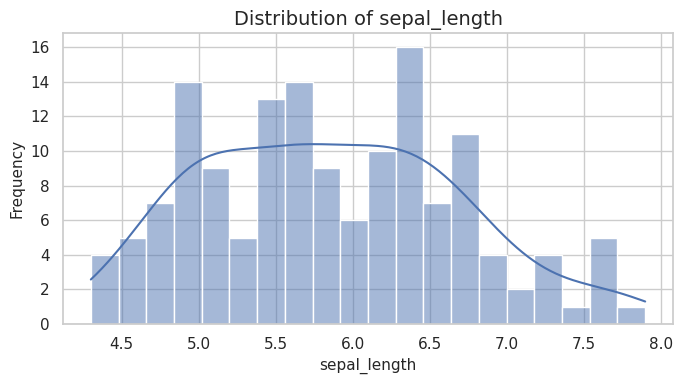

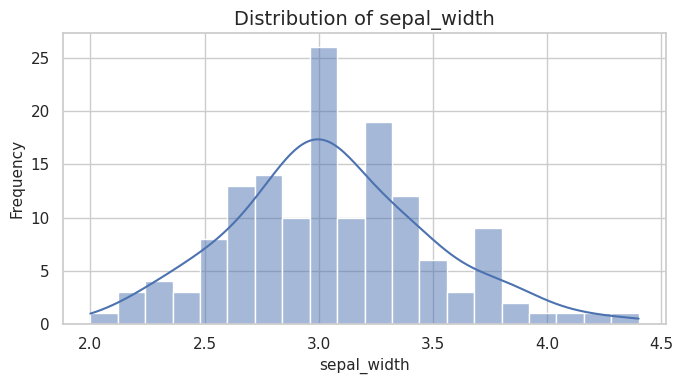

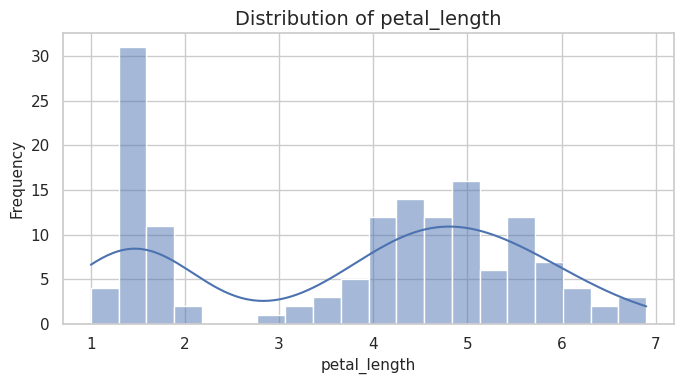

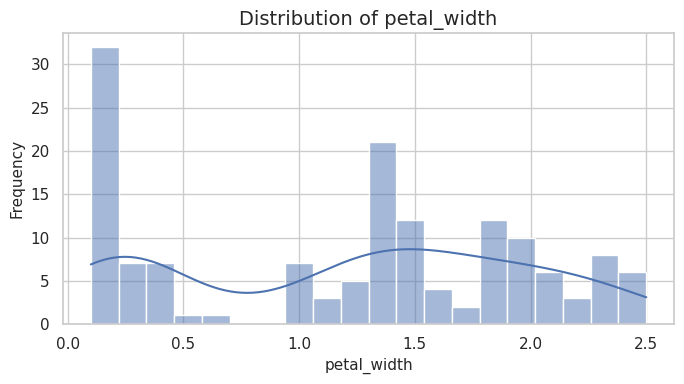

In [ ]:
# Histogram

numeric_cols = iris_eda.select_dtypes(include='number').columns
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=iris_eda, x=col, kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(f'outputs/figures/task2_hist_{col}.png', dpi=300)
    plt.show()

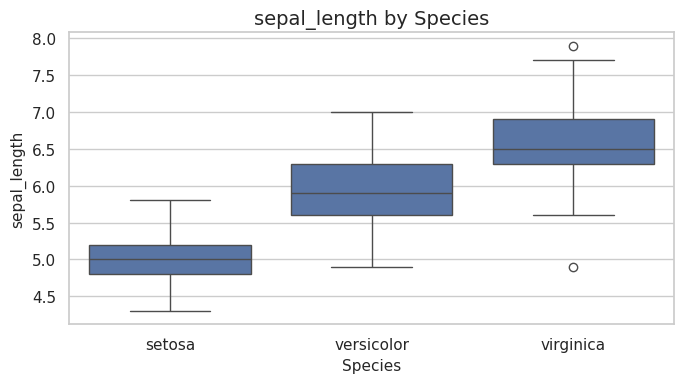

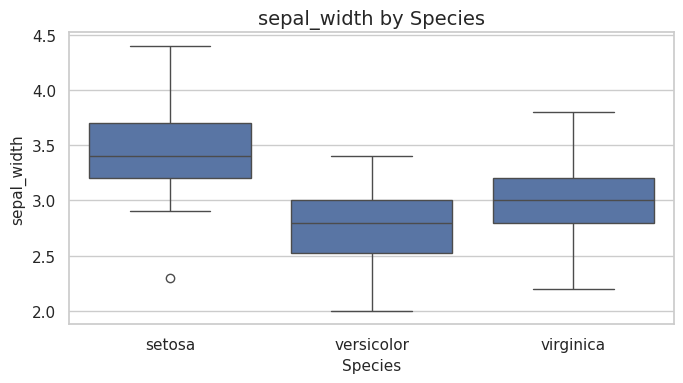

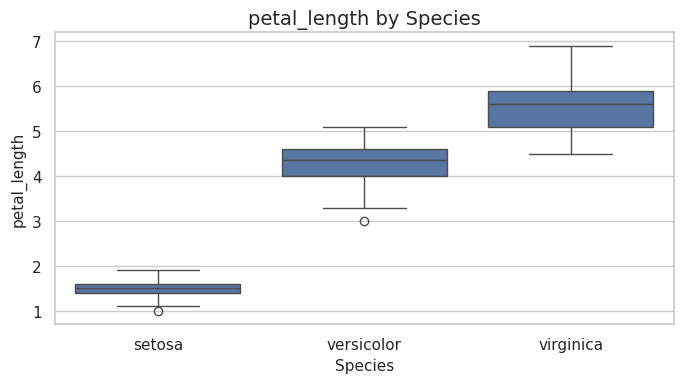

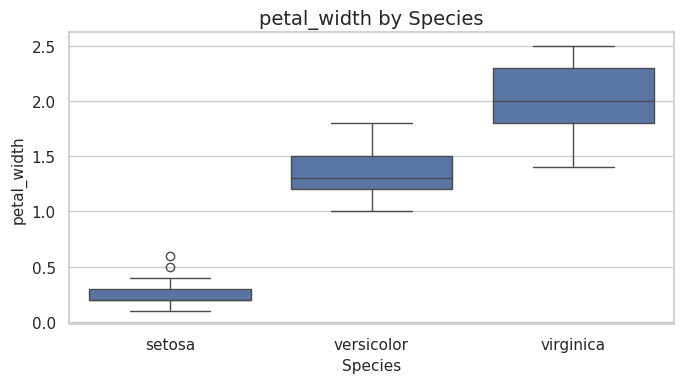

In [ ]:
# Boxplots

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=iris_eda, x='species', y=col)
    plt.title(f'{col} by Species')
    plt.xlabel('Species')
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(f'outputs/figures/task2_box_{col}.png', dpi=300)
    plt.show()

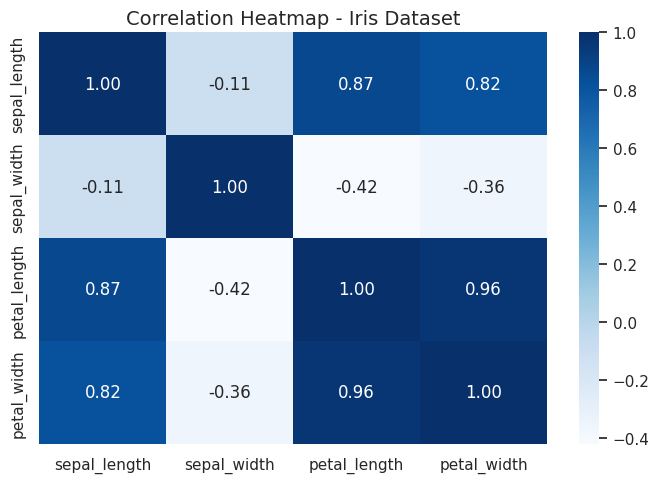

In [ ]:
# Correlation heatmap shows relationships between numeric variables

corr_matrix = iris_eda[numeric_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap - Iris Dataset')
plt.tight_layout()
plt.savefig('outputs/figures/task2_correlation_heatmap.png', dpi=300)
plt.show()

**Basic - Task 03**

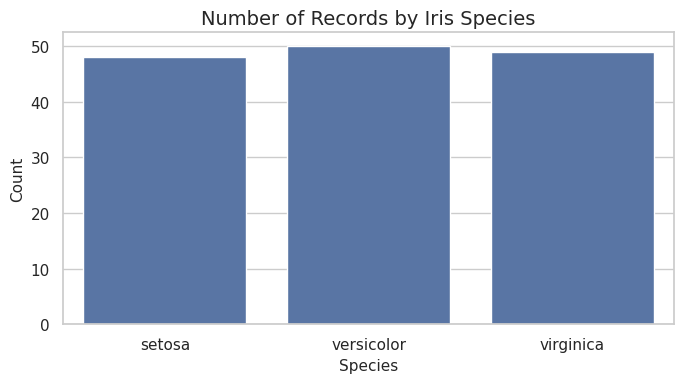

In [ ]:
iris_vis = pd.read_csv('outputs/cleaned_data/iris_cleaned.csv')

plt.figure(figsize=(7, 4))
sns.countplot(data=iris_vis, x='species')
plt.title('Number of Records by Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/figures/task3_species_count_bar.png', dpi=300)
plt.show()

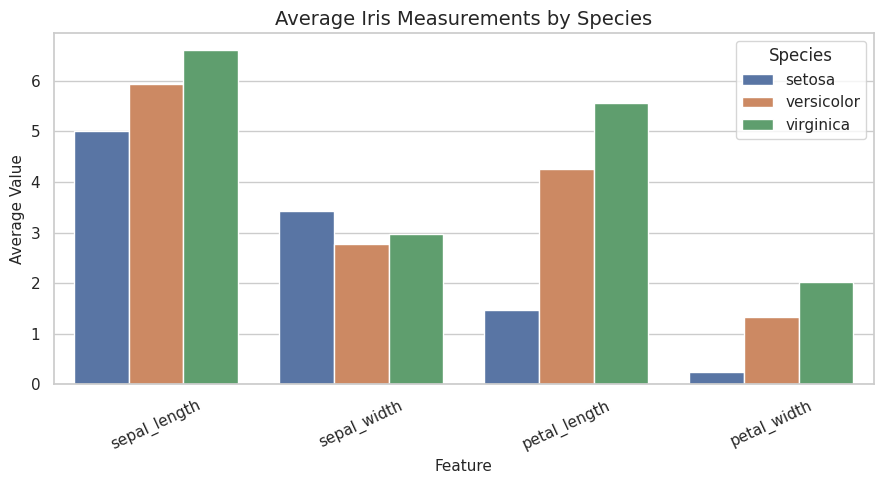

In [ ]:
#average feature bar chart


avg_features = iris_vis.groupby('species')[['sepal_length','sepal_width','petal_length',
'petal_width']].mean()

aavg = avg_features.reset_index().melt(id_vars='species', var_name='feature',
value_name='average_value')

plt.figure(figsize=(9, 5))
sns.barplot(data=aavg, x='feature', y='average_value', hue='species')
plt.title('Average Iris Measurements by Species')
plt.xlabel('Feature')
plt.ylabel('Average Value')
plt.xticks(rotation=25)
plt.legend(title='Species')
plt.tight_layout()
plt.savefig('outputs/figures/task3_average_features_bar.png', dpi=300)
plt.show()

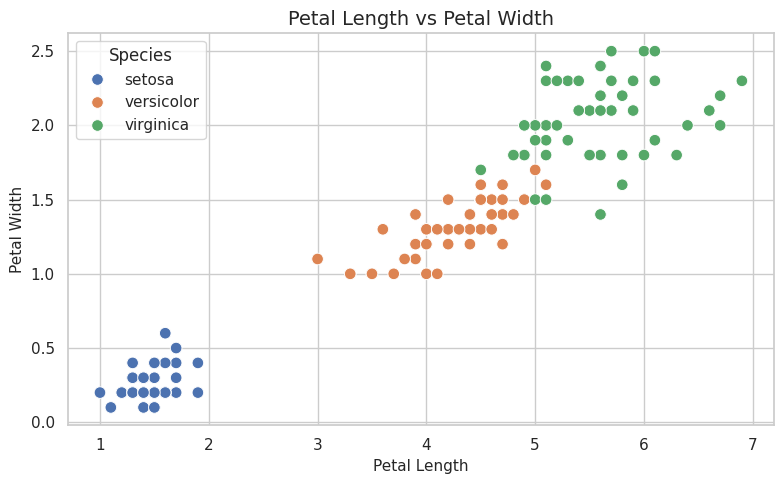

In [ ]:
#scatter plot


plt.figure(figsize=(8, 5))
sns.scatterplot(data=iris_vis, x='petal_length', y='petal_width', hue='species', s=70)

plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend(title='Species')
plt.tight_layout()
plt.savefig('outputs/figures/task3_petal_scatter.png', dpi=300)
plt.show()

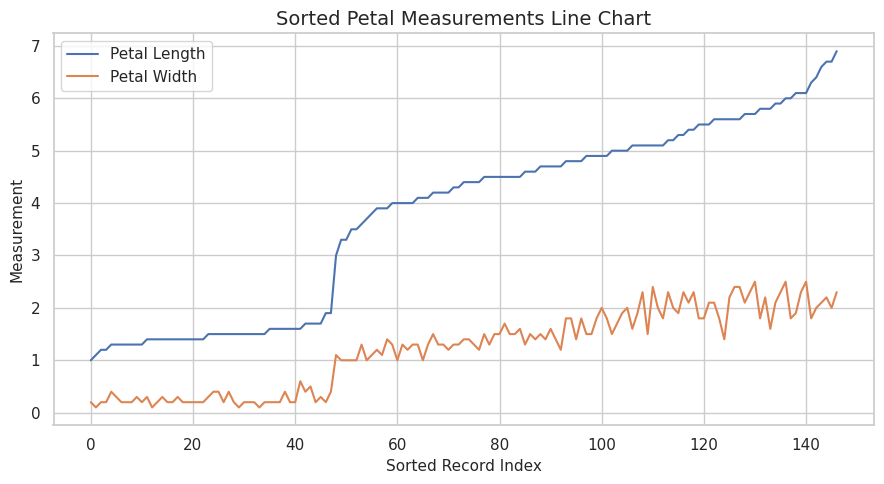

In [ ]:
#line chart


iris_sorted = iris_vis.sort_values('petal_length').reset_index(drop=True)
plt.figure(figsize=(9, 5))
plt.plot(iris_sorted.index, iris_sorted['petal_length'], label='Petal Length')
plt.plot(iris_sorted.index, iris_sorted['petal_width'], label='Petal Width')
plt.title('Sorted Petal Measurements Line Chart')
plt.xlabel('Sorted Record Index')
plt.ylabel('Measurement')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/task3_line_chart.png', dpi=300)
plt.show()

**Intermediate - Task 01**

In [ ]:
import pandas as pd

house = pd.read_csv('house Prediction Data Set.csv')
print(house.head())
print(house.shape)

  0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00
0   0.02731   0.00   7.070  0  0.4690  6.4210  78...                                             
1   0.02729   0.00   7.070  0  0.4690  7.1850  61...                                             
2   0.03237   0.00   2.180  0  0.4580  6.9980  45...                                             
3   0.06905   0.00   2.180  0  0.4580  7.1470  54...                                             
4   0.02985   0.00   2.180  0  0.4580  6.4300  58...                                             
(505, 1)


In [ ]:
house_columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
    'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

house = pd.read_csv(
    'house Prediction Data Set.csv',
    sep=r'\s+',
    header=None,
    names=house_columns
)

print('House dataset shape:', house.shape)
display(house.head())

print('\nData types:')
print(house.dtypes)

print('\nMissing values:')
print(house.isnull().sum())

house.to_csv('outputs/cleaned_data/house_cleaned.csv', index=False)

print('Saved: outputs/cleaned_data/house_cleaned.csv')

House dataset shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2



Data types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Missing values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64
Saved: outputs/cleaned_data/house_cleaned.csv


In [ ]:
#train regression model


# Features and target
X = house.drop('MEDV', axis=1)
y = house['MEDV']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Predictions
y_pred = reg_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Regression Evaluation Results')
print('MAE :', round(mae, 3))
print('MSE :', round(mse, 3))
print('RMSE:', round(rmse, 3))
print('R²  :', round(r2, 3))

Regression Evaluation Results
MAE : 3.189
MSE : 24.291
RMSE: 4.929
R²  : 0.669


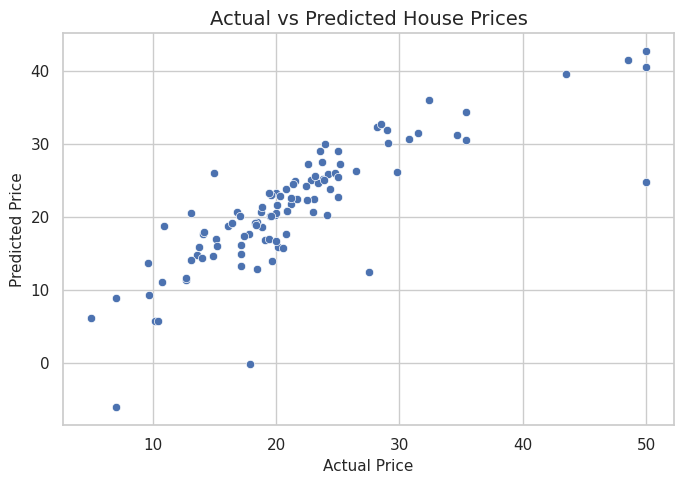

,Feature,Coefficient
5,RM,4.438835
3,CHAS,2.784438
8,RAD,0.262430
2,INDUS,0.040381
1,ZN,0.030110
11,B,0.012351
6,AGE,-0.006296
9,TAX,-0.010647
0,CRIM,-0.113056
12,LSTAT,-0.508571


In [ ]:
#actual vs predicted plot


plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred)

plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.savefig('outputs/figures/task4_actual_vs_predicted.png', dpi=300)
plt.show()

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': reg_model.coef_
}).sort_values(by='Coefficient', ascending=False)
display(coef_df)
coef_df.to_csv('outputs/cleaned_data/task4_regression_coefficients.csv', index=False)

**Intermediate - Task 02**

In [ ]:
stock = pd.read_csv('Stock Prices Data Set.csv')

print('Stock dataset shape:', stock.shape)
display(stock.head())

print('\nData types:')
print(stock.dtypes)

# Standardize column names
stock.columns = stock.columns.str.strip().str.lower()

# Convert date column to datetime
stock['date'] = pd.to_datetime(stock['date'])

print('\nDate range:', stock['date'].min(), 'to', stock['date'].max())

print('\nNumber of stock symbols:', stock['symbol'].nunique())

print('\nSample symbols:')
print(stock['symbol'].unique()[:20])

# Choose one company symbol for the analysis
selected_symbol = 'AAPL'

stock_one = stock[stock['symbol'] == selected_symbol].copy()
stock_one = stock_one.sort_values('date')

print('\nSelected symbol:', selected_symbol)
print('Filtered shape:', stock_one.shape)

display(stock_one.head())

Stock dataset shape: (497472, 7)


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391



Data types:
symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

Date range: 2014-01-02 00:00:00 to 2017-12-29 00:00:00

Number of stock symbols: 505

Sample symbols:
['AAL' 'AAPL' 'AAP' 'ABBV' 'ABC' 'ABT' 'ACN' 'ADBE' 'ADI' 'ADM' 'ADP'
 'ADSK' 'ADS' 'AEE' 'AEP' 'AES' 'AET' 'AFL' 'AGN' 'AIG']

Selected symbol: AAPL
Filtered shape: (1007, 7)


,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


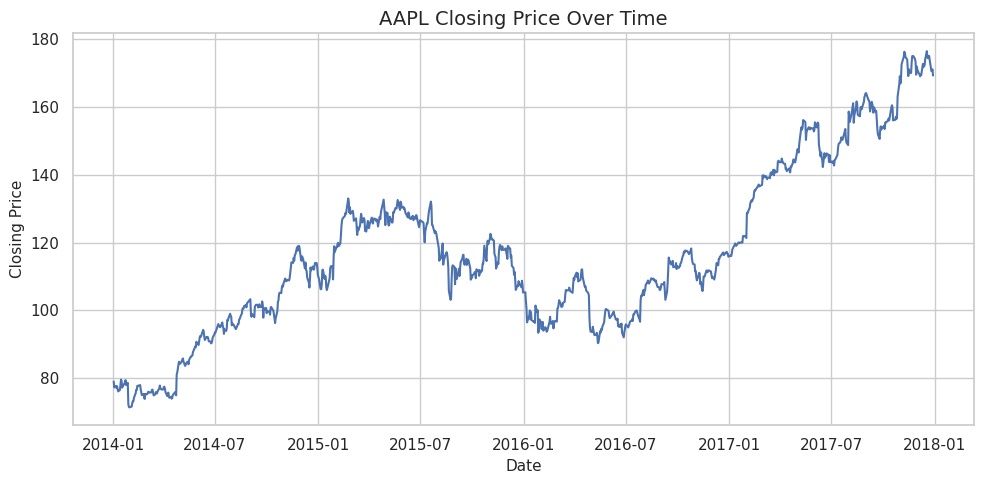

In [ ]:
#closing price trend

plt.figure(figsize=(10, 5))
plt.plot(stock_one['date'], stock_one['close'])
plt.title(f'{selected_symbol} Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.tight_layout()
plt.savefig('outputs/figures/task5_closing_price_trend.png', dpi=300)
plt.show()

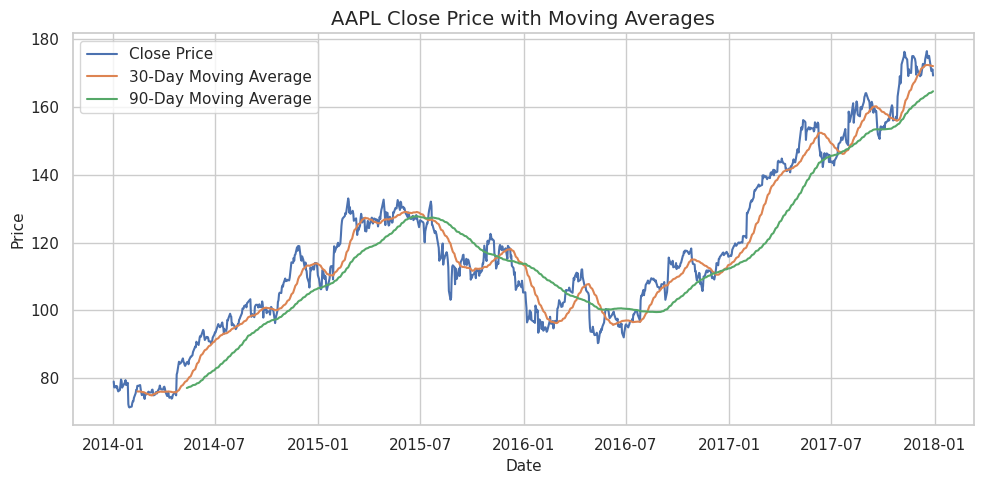

In [ ]:
#moving average smoothing


stock_one['MA_30'] = stock_one['close'].rolling(window=30).mean()
stock_one['MA_90'] = stock_one['close'].rolling(window=90).mean()

plt.figure(figsize=(10, 5))
plt.plot(stock_one['date'], stock_one['close'], label='Close Price')
plt.plot(stock_one['date'], stock_one['MA_30'], label='30-Day Moving Average')
plt.plot(stock_one['date'], stock_one['MA_90'], label='90-Day Moving Average')
plt.title(f'{selected_symbol} Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/task5_moving_averages.png', dpi=300)
plt.show()

stock_one.to_csv('outputs/cleaned_data/stock_selected_symbol_cleaned.csv', index=False)

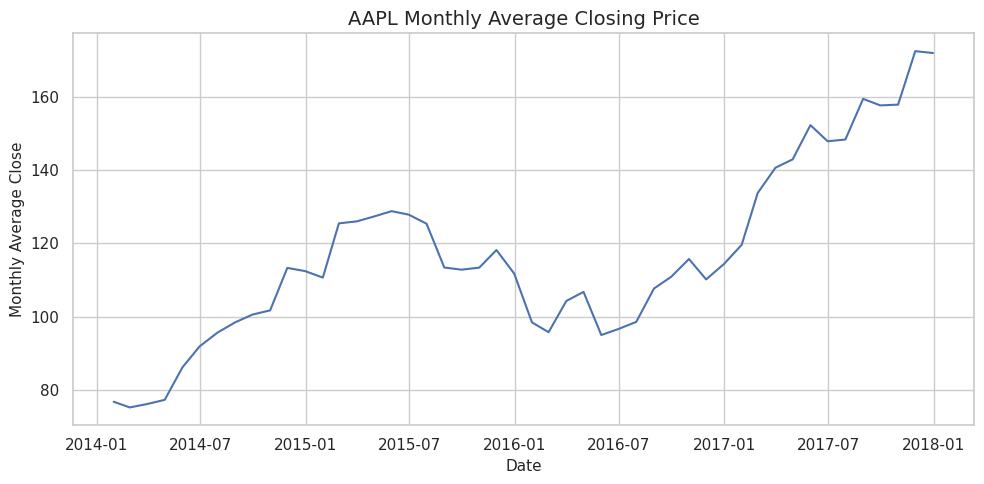

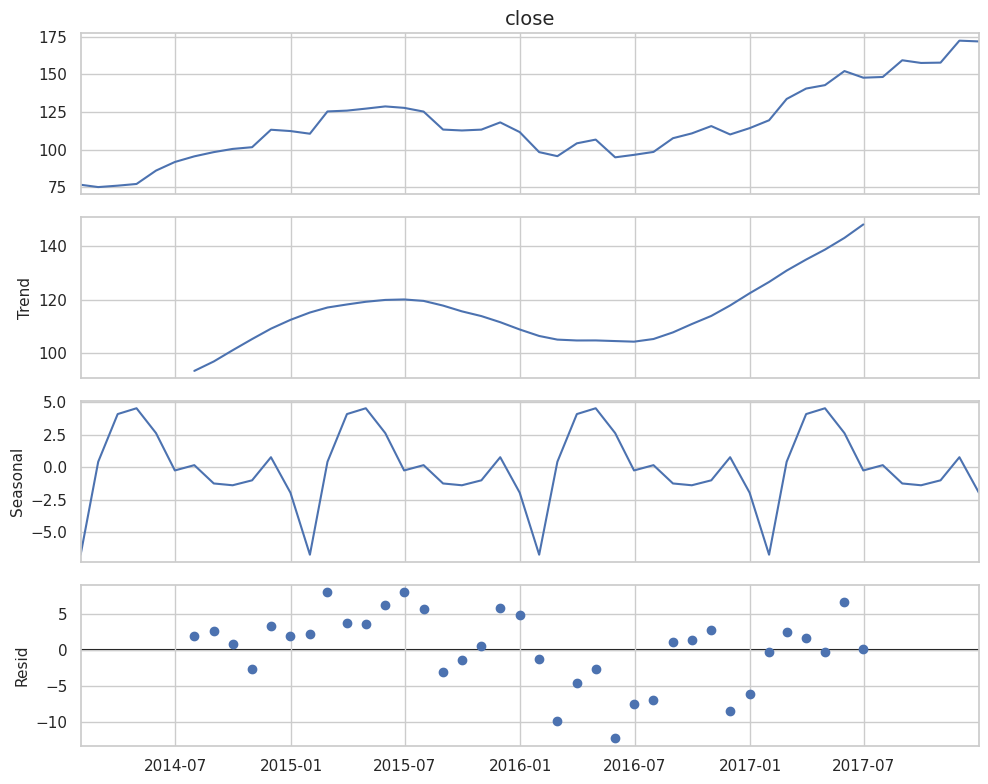

In [ ]:
#monthly resampling and decomposition


from statsmodels.tsa.seasonal import seasonal_decompose

# Set date as index
stock_ts = stock_one.set_index('date')

# Monthly average close price
monthly_close = stock_ts['close'].resample('M').mean().dropna()

plt.figure(figsize=(10, 5))
plt.plot(monthly_close.index, monthly_close.values)
plt.title(f'{selected_symbol} Monthly Average Closing Price')
plt.xlabel('Date')
plt.ylabel('Monthly Average Close')
plt.tight_layout()
plt.savefig('outputs/figures/task5_monthly_average_close.png', dpi=300)
plt.show()

# Seasonal decomposition needs enough monthly observations
result = seasonal_decompose(monthly_close, model='additive', period=12)
fig = result.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.savefig('outputs/figures/task5_seasonal_decomposition.png', dpi=300)
plt.show()

**Intermediate - Task 02**

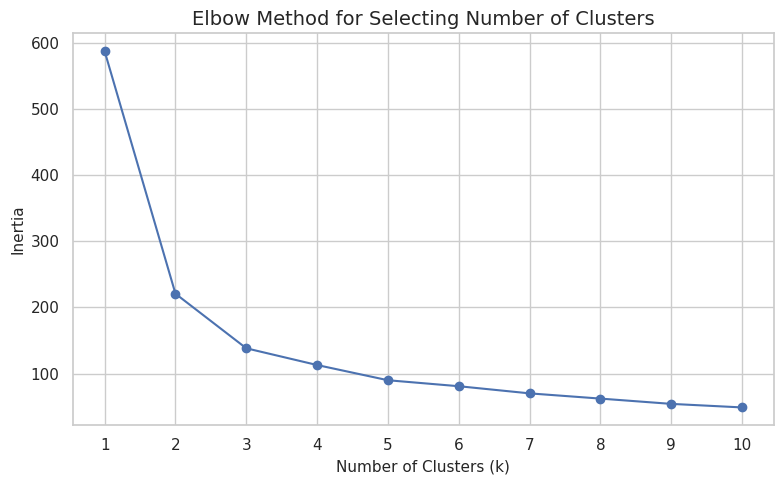

In [ ]:
# elbow method


iris_cluster = pd.read_csv('outputs/cleaned_data/iris_cleaned.csv')
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X_cluster = iris_cluster[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertia_values.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertia_values, marker='o')
plt.title('Elbow Method for Selecting Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(K_range))
plt.tight_layout()
plt.savefig('outputs/figures/task6_elbow_method.png', dpi=300)
plt.show()

Cluster counts:
cluster
0    52
1    48
2    47
Name: count, dtype: int64


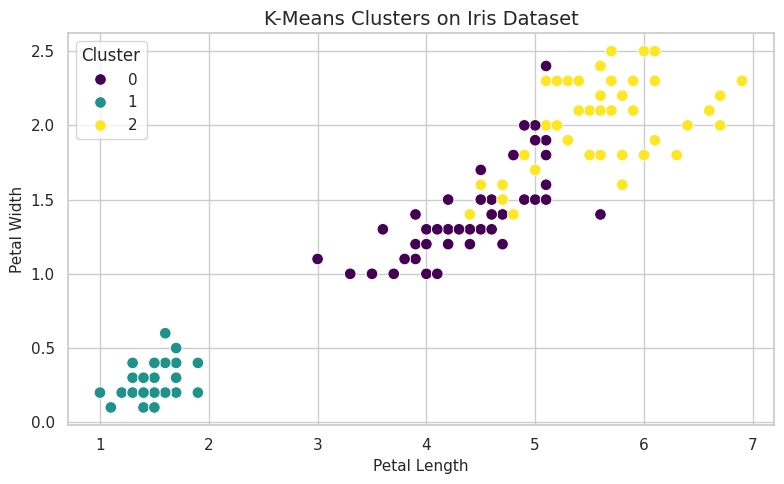

cluster,0,1,2
species,,,
setosa,0,48,0
versicolor,39,0,11
virginica,13,0,36


Saved: outputs/cleaned_data/iris_with_clusters.csv


In [ ]:
#train K-Means and visualize


# Train K-Means using k = 3

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
iris_cluster['cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster counts:')
print(iris_cluster['cluster'].value_counts().sort_index())

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=iris_cluster,
    x='petal_length',
    y='petal_width',
    hue='cluster',
    palette='viridis',
    s=70
)

plt.title('K-Means Clusters on Iris Dataset')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('outputs/figures/task6_kmeans_clusters.png', dpi=300)
plt.show()

# Compare clusters with actual species
comparison = pd.crosstab(iris_cluster['species'], iris_cluster['cluster'])
display(comparison)

iris_cluster.to_csv('outputs/cleaned_data/iris_with_clusters.csv', index=False)
print('Saved: outputs/cleaned_data/iris_with_clusters.csv')

**Advanced - Task 01**

In [27]:
# load and preprocess churn data

churn_train = pd.read_csv('churn-bigml-80.csv')
churn_test = pd.read_csv('churn-bigml-20.csv')

print('Train shape:', churn_train.shape)
print('Test shape:', churn_test.shape)

display(churn_train.head())

print('\nMissing values in train:')
print(churn_train.isnull().sum())

# Combine temporarily to apply same encoding
combined = pd.concat([churn_train, churn_test],
                     axis=0,
                     ignore_index=True)

# Encode binary yes/no columns
combined['International plan'] = combined['International plan'].map({
    'No': 0,
    'Yes': 1
})

combined['Voice mail plan'] = combined['Voice mail plan'].map({
    'No': 0,
    'Yes': 1
})

# Encode State using LabelEncoder
state_encoder = LabelEncoder()

combined['State'] = state_encoder.fit_transform(
    combined['State']
)

# Convert target boolean to int
combined['Churn'] = combined['Churn'].astype(int)

# Split back
train_processed = combined.iloc[:len(churn_train)].copy()
test_processed = combined.iloc[len(churn_train):].copy()

X_train = train_processed.drop('Churn', axis=1)
y_train = train_processed['Churn']

X_test = test_processed.drop('Churn', axis=1)
y_test = test_processed['Churn']

print('Processed X_train shape:', X_train.shape)
print('Processed X_test shape:', X_test.shape)

Train shape: (2666, 20)
Test shape: (667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False



Missing values in train:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64
Processed X_train shape: (2666, 19)
Processed X_test shape: (667, 19)


In [28]:
#model training and evaluation


# Scale data for Logistic Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(model_name, y_true, y_pred):
    print('\n' + '='*50)
    print(model_name)
    print('='*50)
    print('Accuracy :', round(accuracy_score(y_true, y_pred), 4))
    print('Precision:', round(precision_score(y_true, y_pred), 4))
    print('Recall   :', round(recall_score(y_true, y_pred), 4))
    print('F1-score :', round(f1_score(y_true, y_pred), 4))
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred))

# Model 1: Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
evaluate_model('Logistic Regression', y_test, log_pred)

# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
evaluate_model('Decision Tree', y_test, dt_pred)

# Model 3: Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
evaluate_model('Random Forest', y_test, rf_pred)


Logistic Regression
Accuracy : 0.8531
Precision: 0.4595
Recall   : 0.1789
F1-score : 0.2576

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       572
           1       0.46      0.18      0.26        95

    accuracy                           0.85       667
   macro avg       0.67      0.57      0.59       667
weighted avg       0.82      0.85      0.82       667


Decision Tree
Accuracy : 0.9175
Precision: 0.7041
Recall   : 0.7263
F1-score : 0.715

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       572
           1       0.70      0.73      0.72        95

    accuracy                           0.92       667
   macro avg       0.83      0.84      0.83       667
weighted avg       0.92      0.92      0.92       667


Random Forest
Accuracy : 0.946
Precision: 0.9538
Recall   : 0.6526
F1-score : 0.775

Classification Report:
          

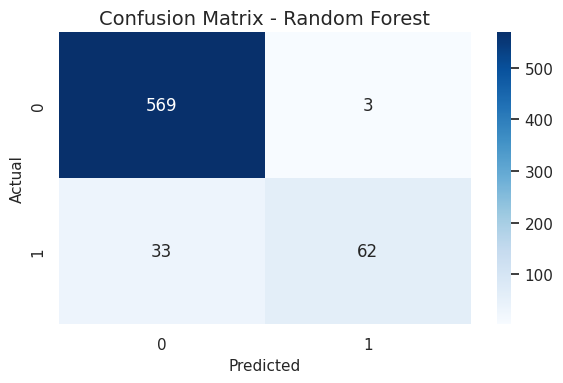

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 score: 0.8078

Tuned Random Forest
Accuracy : 0.955
Precision: 0.9221
Recall   : 0.7474
F1-score : 0.8256

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       572
           1       0.92      0.75      0.83        95

    accuracy                           0.96       667
   macro avg       0.94      0.87      0.90       667
weighted avg       0.95      0.96      0.95       667



,Feature,Importance
6,Total day minutes,0.142646
18,Customer service calls,0.127960
8,Total day charge,0.124651
3,International plan,0.095994
11,Total eve charge,0.065073
9,Total eve minutes,0.059503
16,Total intl calls,0.054161
15,Total intl minutes,0.043831
17,Total intl charge,0.040732
12,Total night minutes,0.033455


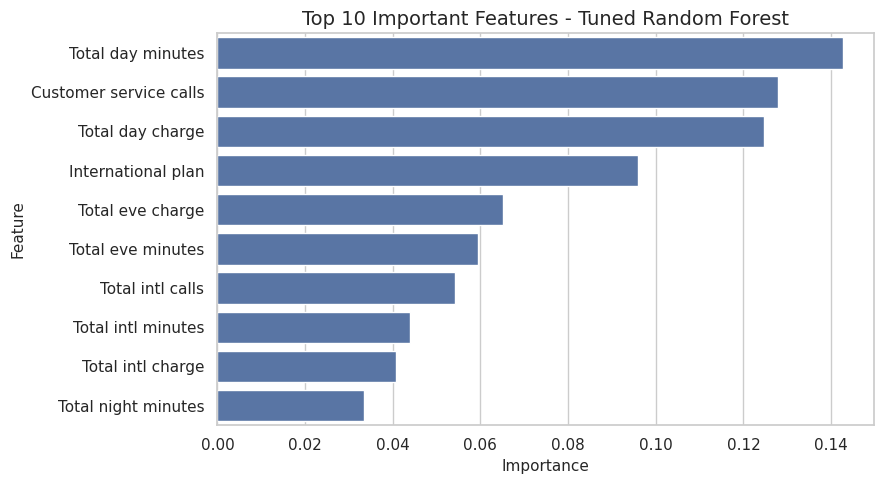

In [29]:
#confusion matrix and tuning


# Confusion matrix for Random Forest

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/figures/task7_confusion_matrix_rf.png', dpi=300)
plt.show()

# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print('Best parameters:', grid_search.best_params_)
print('Best CV F1 score:', round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)
evaluate_model('Tuned Random Forest', y_test, best_pred)

# Feature importance
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(importance_df.head(10))

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Important Features - Tuned Random Forest')
plt.tight_layout()
plt.savefig('outputs/figures/task7_feature_importance.png', dpi=300)
plt.show()

importance_df.to_csv('outputs/cleaned_data/task7_feature_importance.csv', index=False)

**Advanced - Task 02**  (Building Dashboards with Power BI)

In this task, a Customer Churn Analysis Dashboard was developed using Power BI. The dataset was imported, cleaned, and combined before creating interactive visualizations. KPI cards were used to display key metrics such as Total Customers, Churned Customers, Active Customers, and Churn Rate. Additional charts and slicers were added to analyze customer churn patterns and enable interactive data exploration. The dashboard provides meaningful insights into customer behavior and churn trends.

**Advanced - Task 03**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import nltk

from textblob import TextBlob
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

os.makedirs('outputs/cleaned_data', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

sentiment_df = pd.read_csv('Sentiment dataset.csv')

print('Sentiment dataset shape:', sentiment_df.shape)
display(sentiment_df.head())

print('\nColumns:')
print(sentiment_df.columns.tolist())

# Remove extra spaces from column names
sentiment_df.columns = sentiment_df.columns.str.strip()

# Keep useful columns only
text_df = sentiment_df[
    ['Text', 'Sentiment', 'Platform', 'Country', 'Year', 'Month', 'Day', 'Hour']
].copy()

text_df['Text'] = text_df['Text'].astype(str)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

text_df['clean_text'] = text_df['Text'].apply(clean_text)

display(text_df[['Text', 'clean_text', 'Sentiment']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Sentiment dataset shape: (732, 15)


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19



Columns:
['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


,Text,clean_text,Sentiment
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,Positive
1,Traffic was terrible this morning. ...,traffic terrible morning,Negative
2,Just finished an amazing workout! 💪 ...,finished amazing workout,Positive
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,Positive
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,Neutral


In [ ]:
# TEXTBLOB SENTIMENT SCORING


def get_polarity(text):
    return TextBlob(text).sentiment.polarity

def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

text_df['polarity'] = text_df['clean_text'].apply(get_polarity)
text_df['predicted_sentiment'] = text_df['polarity'].apply(classify_sentiment)

print('Predicted sentiment counts:')
print(text_df['predicted_sentiment'].value_counts())

display(
    text_df[
        ['Text', 'clean_text', 'polarity', 'predicted_sentiment', 'Sentiment']
    ].head(10)
)

text_df.to_csv(
    'outputs/cleaned_data/task9_sentiment_results.csv',
    index=False
)

print('Saved: outputs/cleaned_data/task9_sentiment_results.csv')

Predicted sentiment counts:
predicted_sentiment
Neutral     348
Positive    277
Negative    107
Name: count, dtype: int64


,Text,clean_text,polarity,predicted_sentiment,Sentiment
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,0.675000,Positive,Positive
1,Traffic was terrible this morning. ...,traffic terrible morning,-1.000000,Negative,Negative
2,Just finished an amazing workout! 💪 ...,finished amazing workout,0.600000,Positive,Positive
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,0.375000,Positive,Positive
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,0.136364,Positive,Neutral
5,Feeling grateful for the little things in lif...,feeling grateful little thing life,-0.187500,Negative,Positive
6,Rainy days call for cozy blankets and hot coc...,rainy day call cozy blanket hot cocoa,0.025000,Neutral,Positive
7,The new movie release is a must-watch! ...,new movie release mustwatch,0.136364,Positive,Positive
8,Political discussions heating up on the timel...,political discussion heating timeline,0.000000,Neutral,Negative
9,Missing summer vibes and beach days. ...,missing summer vibe beach day,-0.200000,Negative,Neutral


Saved: outputs/cleaned_data/task9_sentiment_results.csv


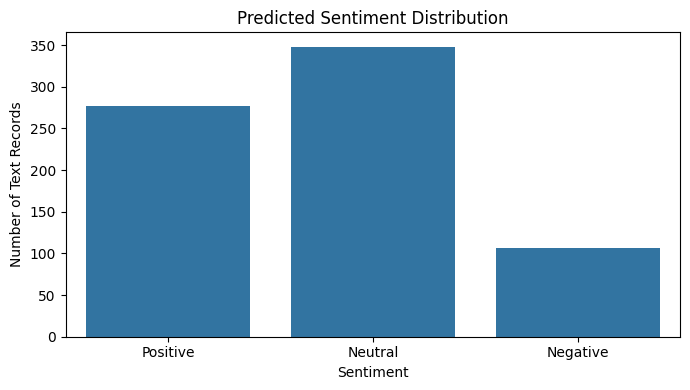

In [ ]:
# SENTIMENT VISUALIZATIONS


plt.figure(figsize=(7, 4))

sns.countplot(
    data=text_df,
    x='predicted_sentiment',
    order=['Positive', 'Neutral', 'Negative']
)

plt.title('Predicted Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Text Records')
plt.tight_layout()

plt.savefig(
    'outputs/figures/task9_sentiment_distribution.png',
    dpi=300
)

plt.show()

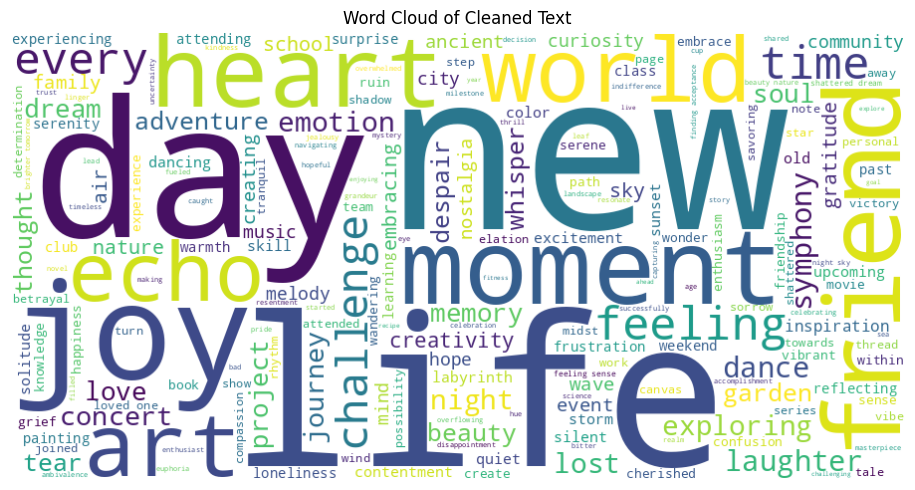

In [ ]:
# WORD CLOUD


all_words = ' '.join(text_df['clean_text'].dropna())

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Text')
plt.tight_layout()

plt.savefig(
    'outputs/figures/task9_wordcloud.png',
    dpi=300
)

plt.show()

predicted_sentiment,Negative,Neutral,Positive
Sentiment_clean,,,
Acceptance,2,5,1
Accomplishment,0,0,3
Admiration,0,2,2
Adoration,0,0,2
Adrenaline,0,0,1
...,...,...,...
Winter Magic,0,0,1
Wonder,0,3,0
Wonderment,0,1,0


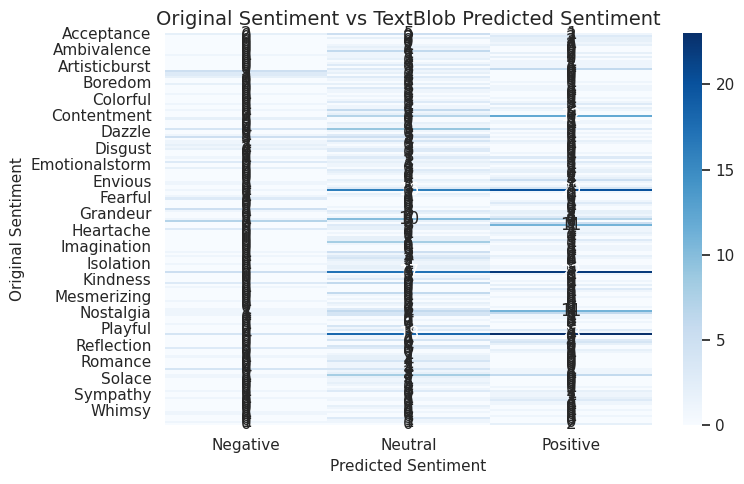

In [30]:
# COMPARE ORIGINAL SENTIMENT WITH TEXTBLOB RESULT


text_df['Sentiment_clean'] = (
    text_df['Sentiment']
    .astype(str)
    .str.strip()
    .str.title()
)

comparison_table = pd.crosstab(
    text_df['Sentiment_clean'],
    text_df['predicted_sentiment']
)

display(comparison_table)

plt.figure(figsize=(8, 5))

sns.heatmap(
    comparison_table,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Original Sentiment vs TextBlob Predicted Sentiment')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Original Sentiment')
plt.tight_layout()

plt.savefig(
    'outputs/figures/task9_sentiment_comparison_heatmap.png',
    dpi=300
)

plt.show()